In [4]:
from matplotlib import pyplot as plt
import numpy as np

import mne
import mne_icalabel
from asrpy import ASR

In [5]:
%matplotlib ipympl

In [8]:
def load_subject_data(file_path):
    # Load the .set file using mne
    return mne.io.read_raw_eeglab(file_path, preload=True)

def notch_bandpass_rereference(data: mne.io.Raw, notch_freq=60, l_freq=1, h_freq=50):
    dataCopy = data.copy()
    dataCopy.notch_filter(freqs=notch_freq, verbose=False)
    dataCopy.filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
    # Rereference the data to the average of all electrodes
    return dataCopy.set_eeg_reference('average', verbose=False)

def epoch_data(data: mne.io.Raw, e_start, e_end):
    return mne.Epochs(data, tmin=e_start, tmax=e_end, baseline=None, preload=True, verbose=False)

def bandpass_filter(data: mne.io.Raw, l_freq, h_freq):
    return data.copy().filter(l_freq=l_freq, h_freq=h_freq, method="fir", verbose=False)

def run_ica(data: mne.io.Raw, remove_labels, n_components=15, plot_sources=False):
    dataCopy = data.copy()
    ica = mne.preprocessing.ICA(n_components=n_components, random_state=0, method='infomax', fit_params=dict(extended=True))
    ica.fit(dataCopy, verbose=False)

    labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')
    print(labels)
    ica.exclude = [idx for idx, label in enumerate(labels['labels']) if label in remove_labels]
    if plot_sources:
        _ = ica.plot_sources(dataCopy)
    return ica.apply(dataCopy, verbose=False)

def auto_reject_channels(data: mne.io.Raw, z_threshold=3.0):
    """Automatically reject channels based on z-score of their variance."""
    dataCopy = data.copy()
    # Calculate variance for each channel
    variances = np.var(dataCopy.get_data(), axis=1)
    # Calculate z-scores
    z_scores = np.abs((variances - np.mean(variances)) / np.std(variances))
    # Find bad channels
    bad_channels = [ch for ch, z in zip(dataCopy.ch_names, z_scores) if z > z_threshold]
    dataCopy.info['bads'].extend(bad_channels)
    dataCopy.interpolate_bads()
    print(f"Bad channels: {bad_channels}")
    return dataCopy

def auto_reject_trials(epochs: mne.Epochs, z_threshold=2.0):
    """Automatically reject trials based on z-score of their variance."""
    epochsCopy = epochs.copy()
    # Calculate variance for each trial
    variances = np.var(epochsCopy.get_data(), axis=(1, 2))
    # Calculate z-scores
    z_scores = np.abs((variances - np.mean(variances)) / np.std(variances))
    # Find bad trials
    bad_trials = np.where(z_scores > z_threshold)[0]
    epochsCopy.drop(bad_trials)
    print(f"Bad trials: {bad_trials}")
    return epochsCopy

In [13]:
subject = '001'
run = 3

e_start = -1
e_end = 2

b_start = -1
b_end = 0

file_path = f"EEG Motor Movement:Imagery Dataset/sub-{subject}/eeg/sub-{subject}_task-motion_run-{run}_eeg.set"

data = notch_bandpass_rereference(load_subject_data(file_path))
data = auto_reject_channels(data)
data = run_ica(data, ['eye blink', 'heart beat', 'muscle artifact', 'other'])
data = epoch_data(data, e_start, e_end)
data = auto_reject_trials(data)
processed_data = data.apply_baseline((b_start, b_end))

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 100.0 mm
Computing interpolation matrix from 62 sensor positions
Interpolating 2 sensors
Bad channels: ['Fp1', 'Fp2']


/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_54235/424497136.py:23: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(dataCopy, ica, method='iclabel')


{'y_pred_proba': array([0.9955195 , 0.9942186 , 0.9219666 , 0.45797592, 0.9878496 ,
       0.61077857, 0.9750474 , 0.78269064, 0.52996564, 0.8348813 ,
       0.84465724, 0.36981514, 0.89366424, 0.90089333, 0.5079317 ],
      dtype=float32), 'labels': ['eye blink', 'brain', 'eye blink', 'other', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'muscle artifact', 'other', 'other', 'other']}
Dropped 1 epoch: 16
Bad trials: [16]
Applying baseline correction (mode: mean)


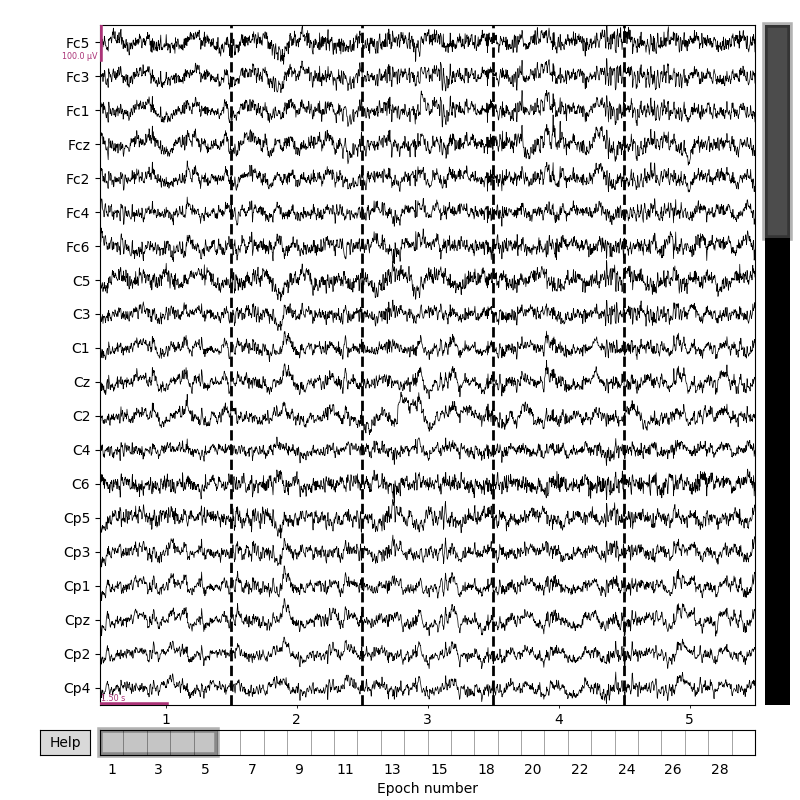

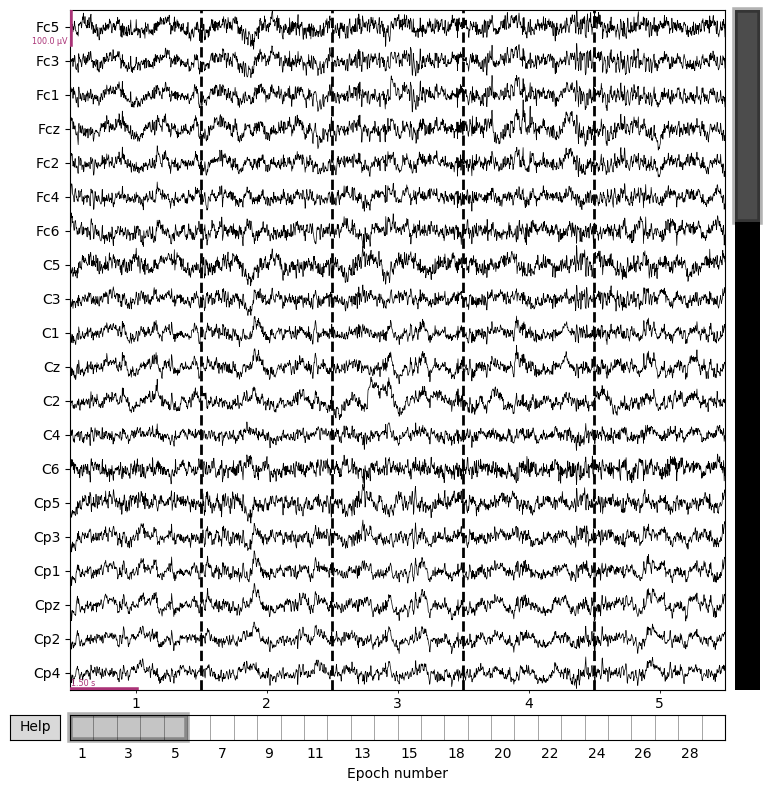

In [14]:
processed_data.plot(scalings=dict(eeg=0.5e-4), n_epochs=5)

No projector specified for this dataset. Please consider the method self.add_proj.


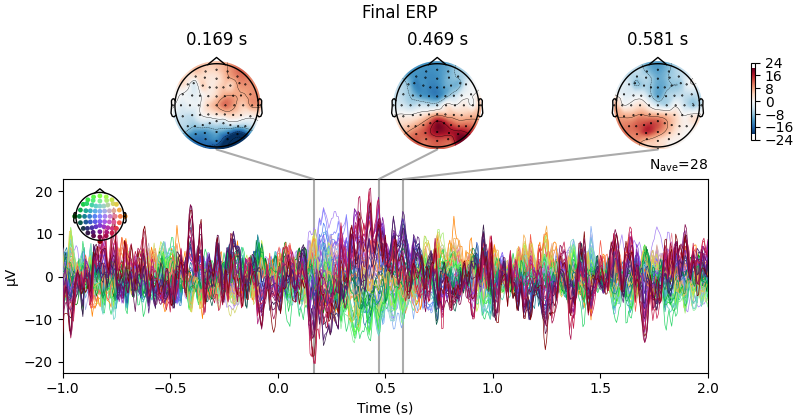

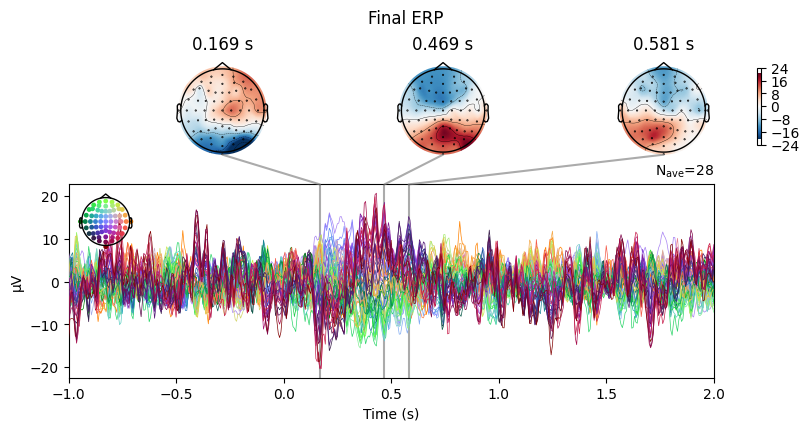

In [15]:
# Compute the average across all epochs to get the ERP
evoked = processed_data.average()

# Plot the ERP with topography
evoked.plot_joint(title='Final ERP')

In [17]:
# Save the processed data to a file
processed_data.save(f'processed_data/sub-{subject}_run-{run}_processed-epo.fif', overwrite=True)


Overwriting existing file.
Overwriting existing file.
